# From the Dengue Exercise to ARGO - Lane A (the real experience: you prompt, the agent builds)

**SISMID 2026 - Day 2, 1:30.** You drive a coding agent (Codex, Claude Code, or Antigravity
CLI) to grow the static dengue model into ARGO, and you keep the judgment. For each step:
read the goal, paste the **prompt**, run the code the agent writes, and check the RMSE.

> Each prompt produces roughly the matching cell in the **Lane B** notebook. Not set up
> with an agent yet? Use Lane B. Data: `MX_Dengue_trends.csv`.


## Step 0: load and recap the static model

> *Load MX_Dengue_trends.csv (Dengue CDC = monthly cases; dengue, sintomas de dengue,*
> *mosquito, dengue sintomas = search). Refit the Part 1 static model: least squares of*
> *Dengue CDC on 'dengue' over the first 36 months, predict 2007-2011, and report the RMSE.*


static RMSE (2007-2011): 4968.4


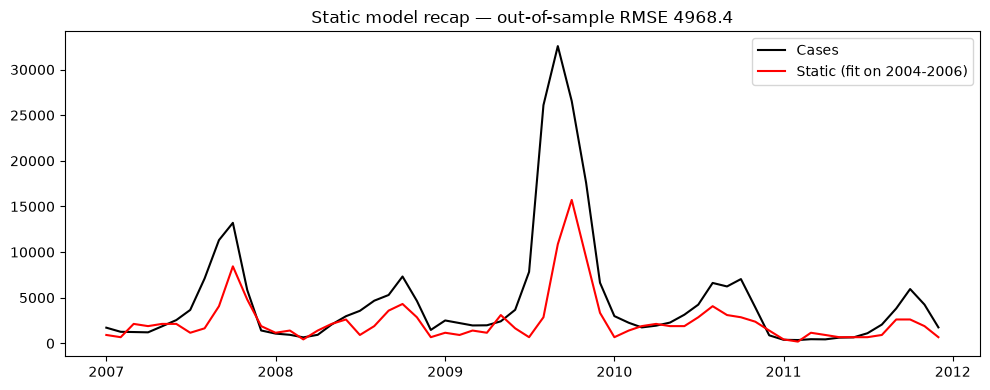

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, os
from sklearn.linear_model import LinearRegression

CANDIDATES = ['../data/MX_Dengue_trends.csv', 'data/MX_Dengue_trends.csv', './MX_Dengue_trends.csv']
path = next((p for p in CANDIDATES if os.path.exists(p)), CANDIDATES[0])
df = pd.read_csv(path)
df['Date'] = pd.to_datetime(df['Date'])

SEARCH = ['dengue', 'sintomas de dengue', 'mosquito', 'dengue sintomas']
TARGET = 'Dengue CDC'

def rmse(truth, pred):
    return float(np.sqrt(np.mean((np.asarray(truth) - np.asarray(pred))**2)))

# Refit the Part 1 static model: least squares of Dengue CDC on 'dengue', first 36 months.
df_train = df.iloc[:36]
df_valid = df.iloc[36:].copy()

static_model = LinearRegression().fit(df_train[['dengue']], df_train[TARGET])
pred_static = static_model.predict(df_valid[['dengue']])

static_rmse = rmse(df_valid[TARGET], pred_static)
print('static RMSE (2007-2011):', round(static_rmse, 1))

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_static, 'r', label='Static (fit on 2004-2006)')
plt.legend(); plt.title(f'Static model recap — out-of-sample RMSE {static_rmse:.1f}')
plt.tight_layout()
plt.savefig('../mx_dengue_static_recap.png', dpi=150)
plt.show()


## Step 1: dynamic (sliding-window) training

> *Write a sliding-window dynamic model: for each month from 2007 on, fit least squares on*
> *the previous 36 months and predict the next month. Do it with just 'dengue' first. Plot*
> *dynamic vs static vs actual and report both RMSEs. Which is better?*


static RMSE (2007-2011):  4968.4
dynamic RMSE (2007-2011): 4040.0
dynamic is better


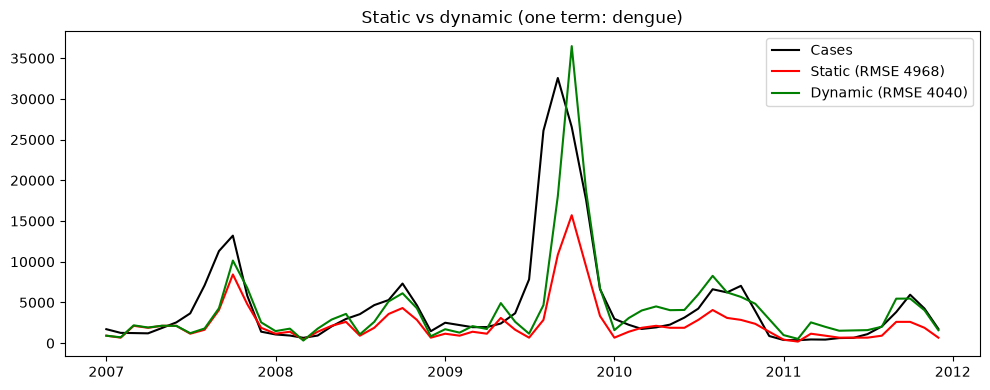

In [2]:
def dynamic_predict(frame, features, window=36):
    preds = np.zeros(frame.shape[0] - window)
    for month in range(window, frame.shape[0]):
        tr = frame.iloc[month - window:month]
        lr = LinearRegression().fit(tr[features], tr[TARGET])
        preds[month - window] = lr.predict(frame.iloc[month:month + 1][features])[0]
    return preds

pred_dyn = dynamic_predict(df, ['dengue'])
dyn_rmse = rmse(df_valid[TARGET], pred_dyn)

print('static RMSE (2007-2011): ', round(static_rmse, 1))
print('dynamic RMSE (2007-2011):', round(dyn_rmse, 1))
print('dynamic is better' if dyn_rmse < static_rmse else 'static is better')

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_static, 'r', label=f'Static (RMSE {static_rmse:.0f})')
plt.plot(df_valid['Date'], pred_dyn, 'g', label=f'Dynamic (RMSE {dyn_rmse:.0f})')
plt.legend(); plt.title('Static vs dynamic (one term: dengue)')
plt.tight_layout()
plt.savefig('../mx_dengue_static_vs_dynamic.png', dpi=150)
plt.show()


## Step 2: add all four search terms

> *Extend the dynamic model to use all four search terms as predictors. Recompute the RMSE*
> *and compare to the one-term dynamic model.*


dynamic (1 term) RMSE:    4040.0
dynamic (all terms) RMSE: 3683.6
all-terms is better


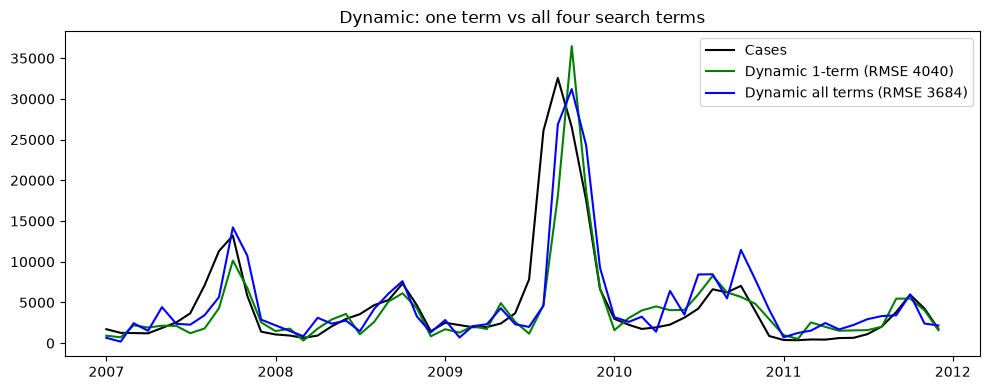

In [3]:
pred_dyn_all = dynamic_predict(df, SEARCH)
dyn_all_rmse = rmse(df_valid[TARGET], pred_dyn_all)

print('dynamic (1 term) RMSE:   ', round(dyn_rmse, 1))
print('dynamic (all terms) RMSE:', round(dyn_all_rmse, 1))
print('all-terms is better' if dyn_all_rmse < dyn_rmse else '1-term is better')

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_dyn, 'g', label=f'Dynamic 1-term (RMSE {dyn_rmse:.0f})')
plt.plot(df_valid['Date'], pred_dyn_all, 'b', label=f'Dynamic all terms (RMSE {dyn_all_rmse:.0f})')
plt.legend(); plt.title('Dynamic: one term vs all four search terms')
plt.tight_layout()
plt.savefig('../mx_dengue_dynamic_1term_vs_allterms.png', dpi=150)
plt.show()


## Step 3: add autoregression = ARGO

> *Add autoregression: include last month's and the month-before's Dengue CDC (ar1, ar2)*
> *as extra features (shift the case column; the first two rows will be NaN). Refit the*
> *sliding window with search terms + ar1 + ar2. This is ARGO. Compare its RMSE to the rest.*


dynamic (1 term) RMSE:     4040.0
dynamic (all terms) RMSE:  3683.6
ARGO (terms + ar1 + ar2):  3391.2


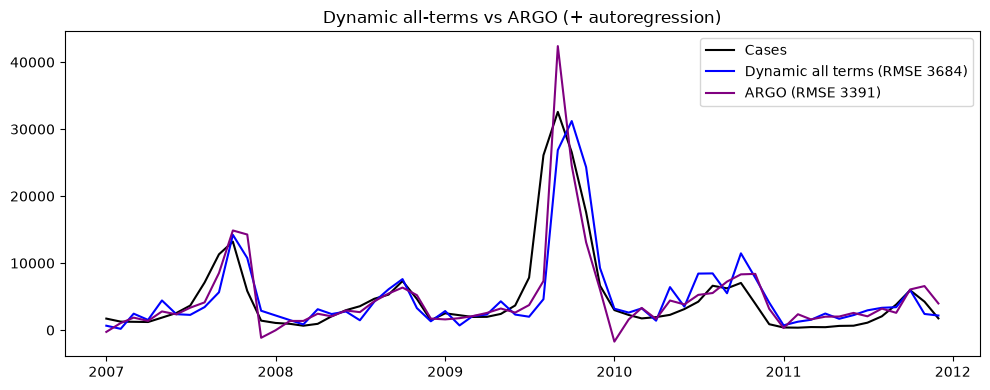

In [4]:
dfa = df.copy()
dfa['ar1'] = dfa[TARGET].shift(1)
dfa['ar2'] = dfa[TARGET].shift(2)
ARGO_FEATURES = SEARCH + ['ar1', 'ar2']

def dynamic_predict_ar(frame, features, window=36):
    preds = np.zeros(frame.shape[0] - window)
    for month in range(window, frame.shape[0]):
        tr = frame.iloc[max(month - window, 2):month]  # first 2 rows have NaN AR terms
        lr = LinearRegression().fit(tr[features], tr[TARGET])
        preds[month - window] = lr.predict(frame.iloc[month:month + 1][features])[0]
    return preds

pred_argo = dynamic_predict_ar(dfa, ARGO_FEATURES)
argo_rmse = rmse(df_valid[TARGET], pred_argo)

print('dynamic (1 term) RMSE:    ', round(dyn_rmse, 1))
print('dynamic (all terms) RMSE: ', round(dyn_all_rmse, 1))
print('ARGO (terms + ar1 + ar2): ', round(argo_rmse, 1))

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_dyn_all, 'b', label=f'Dynamic all terms (RMSE {dyn_all_rmse:.0f})')
plt.plot(df_valid['Date'], pred_argo, 'purple', label=f'ARGO (RMSE {argo_rmse:.0f})')
plt.legend(); plt.title('Dynamic all-terms vs ARGO (+ autoregression)')
plt.tight_layout()
plt.savefig('../mx_dengue_argo.png', dpi=150)
plt.show()


## Aside: log(1+x) on both x and y, compared back on the original scale

Case counts and search interest are both right-skewed and non-negative, so it's natural
to fit in `log1p` space (`log(1+x)`) and back-transform predictions with `expm1` before
scoring RMSE — so this is still an apples-to-apples comparison against the raw-scale
models above.


dynamic all terms  — raw RMSE: 3683.6  | log1p/expm1 RMSE: 4422.5
ARGO (+ar1,ar2)     — raw RMSE: 3391.2  | log1p/expm1 RMSE: 3397.1


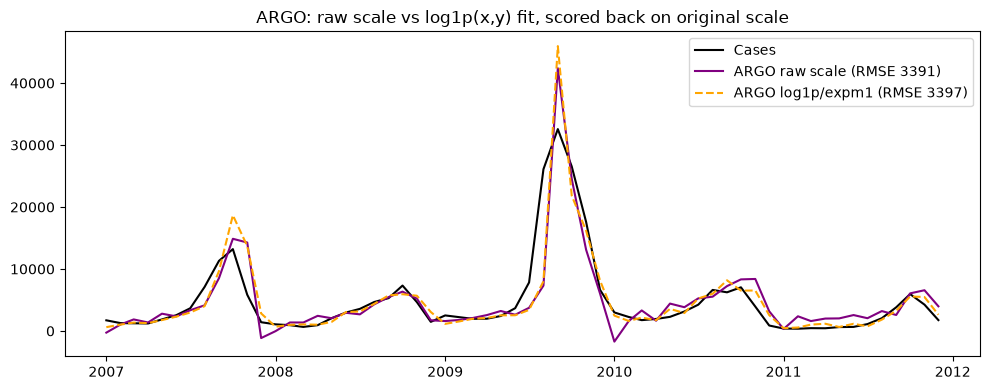

In [5]:
def dynamic_predict_log(frame, features, window=36):
    """Same sliding-window fit, but on log1p(features) -> log1p(target), then expm1 back."""
    preds = np.zeros(frame.shape[0] - window)
    log_target = np.log1p(frame[TARGET])
    log_features = np.log1p(frame[features])
    for month in range(window, frame.shape[0]):
        tr = slice(max(month - window, 2), month)
        lr = LinearRegression().fit(log_features.iloc[tr], log_target.iloc[tr])
        pred_log = lr.predict(log_features.iloc[month:month + 1])[0]
        preds[month - window] = np.expm1(pred_log)
    return preds

pred_dyn_all_log = dynamic_predict_log(df, SEARCH)
pred_argo_log = dynamic_predict_log(dfa, ARGO_FEATURES)

dyn_all_log_rmse = rmse(df_valid[TARGET], pred_dyn_all_log)
argo_log_rmse = rmse(df_valid[TARGET], pred_argo_log)

print('dynamic all terms  — raw RMSE:', round(dyn_all_rmse, 1), ' | log1p/expm1 RMSE:', round(dyn_all_log_rmse, 1))
print('ARGO (+ar1,ar2)     — raw RMSE:', round(argo_rmse, 1), ' | log1p/expm1 RMSE:', round(argo_log_rmse, 1))

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_argo, 'purple', label=f'ARGO raw scale (RMSE {argo_rmse:.0f})')
plt.plot(df_valid['Date'], pred_argo_log, 'orange', ls='--', label=f'ARGO log1p/expm1 (RMSE {argo_log_rmse:.0f})')
plt.legend(); plt.title('ARGO: raw scale vs log1p(x,y) fit, scored back on original scale')
plt.tight_layout()
plt.savefig('../mx_dengue_argo_log1p_vs_raw.png', dpi=150)
plt.show()


## Step 4: compare everything

> *Print a table of out-of-sample RMSE for static, dynamic-1-term, dynamic-all-terms, and*
> *ARGO, and overlay all four predictions against actual cases.*


model                           RMSE
static (1 term)                   4968.4
dynamic (1 term)                  4040.0
dynamic (all terms)               3683.6
dynamic (all terms, log1p)        4422.5
ARGO (+ar1, ar2)                  3391.2
ARGO (+ar1, ar2, log1p)           3397.1


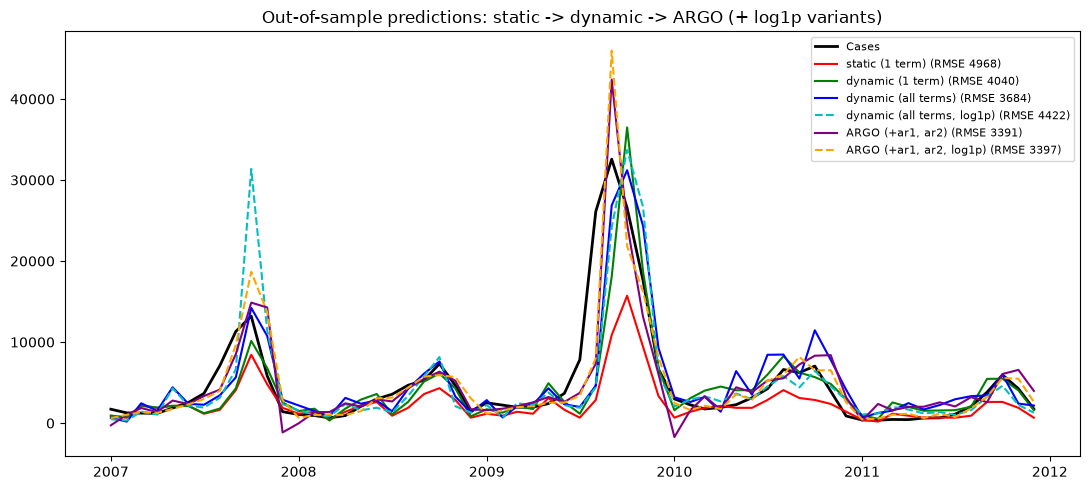

In [6]:
results = [
    ('static (1 term)',            pred_static,       static_rmse),
    ('dynamic (1 term)',           pred_dyn,          dyn_rmse),
    ('dynamic (all terms)',        pred_dyn_all,      dyn_all_rmse),
    ('dynamic (all terms, log1p)', pred_dyn_all_log,  dyn_all_log_rmse),
    ('ARGO (+ar1, ar2)',           pred_argo,         argo_rmse),
    ('ARGO (+ar1, ar2, log1p)',    pred_argo_log,     argo_log_rmse),
]

print(f"{'model':30s}  RMSE")
for name, _, r in results:
    print(f'{name:30s}  {r:8.1f}')

plt.figure(figsize=(11, 5))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', lw=2, label='Cases')
colors = ['r', 'g', 'b', 'c', 'purple', 'orange']
styles = ['-', '-', '-', '--', '-', '--']
for (name, pred, r), color, style in zip(results, colors, styles):
    plt.plot(df_valid['Date'], pred, color, ls=style, label=f'{name} (RMSE {r:.0f})')
plt.legend(fontsize=8); plt.title('Out-of-sample predictions: static -> dynamic -> ARGO (+ log1p variants)')
plt.tight_layout()
plt.savefig('../mx_dengue_all_models_compared.png', dpi=150)
plt.show()


## Stretch: full ARGO with Lasso

> *Refit the ARGO features with a Lasso (L1) model inside the sliding window (standardize*
> *the features first). Compare its RMSE to plain least-squares ARGO. Note which terms Lasso*
> *keeps.*


ARGO (least squares) RMSE: 3391.2
ARGO (Lasso)         RMSE: 3183.6

How often each term survived Lasso (nonzero coef), out of 60 monthly refits:
  sintomas de dengue   kept  60/60 months (100%)
  dengue sintomas      kept  60/60 months (100%)
  ar1                  kept  60/60 months (100%)
  ar2                  kept  59/60 months (98%)
  mosquito             kept  55/60 months (92%)
  dengue               kept  51/60 months (85%)


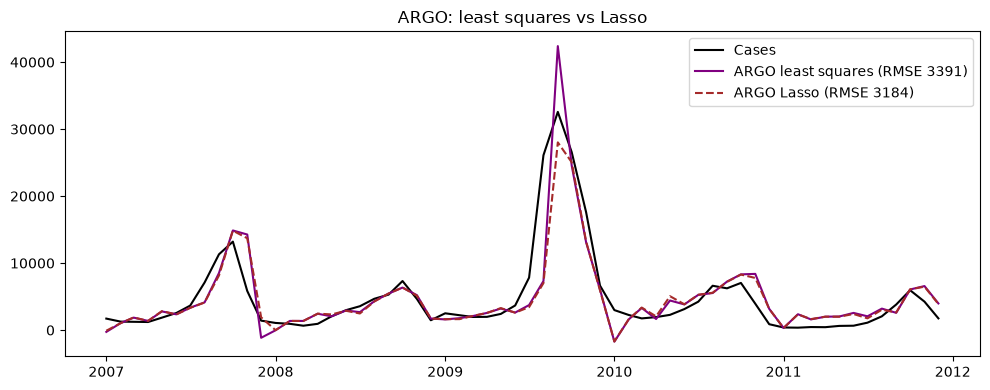

In [7]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def dynamic_predict_lasso(frame, features, window=36):
    preds = np.zeros(frame.shape[0] - window)
    kept_counts = np.zeros(len(features))
    for month in range(window, frame.shape[0]):
        tr = frame.iloc[max(month - window, 2):month]
        model = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50000))
        model.fit(tr[features], tr[TARGET])
        preds[month - window] = model.predict(frame.iloc[month:month + 1][features])[0]
        kept_counts += (model.named_steps['lassocv'].coef_ != 0)
    return preds, kept_counts

pred_argo_lasso, kept_counts = dynamic_predict_lasso(dfa, ARGO_FEATURES)
argo_lasso_rmse = rmse(df_valid[TARGET], pred_argo_lasso)

print('ARGO (least squares) RMSE:', round(argo_rmse, 1))
print('ARGO (Lasso)         RMSE:', round(argo_lasso_rmse, 1))
print()
print('How often each term survived Lasso (nonzero coef), out of', len(df_valid), 'monthly refits:')
for feat, cnt in sorted(zip(ARGO_FEATURES, kept_counts), key=lambda x: -x[1]):
    print(f'  {feat:20s} kept {int(cnt):3d}/{len(df_valid)} months ({100*cnt/len(df_valid):.0f}%)')

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_argo, 'purple', label=f'ARGO least squares (RMSE {argo_rmse:.0f})')
plt.plot(df_valid['Date'], pred_argo_lasso, 'brown', ls='--', label=f'ARGO Lasso (RMSE {argo_lasso_rmse:.0f})')
plt.legend(); plt.title('ARGO: least squares vs Lasso')
plt.tight_layout()
plt.savefig('../mx_dengue_argo_lasso.png', dpi=150)
plt.show()


## Aside: Lasso + log1p, so predicted cases can't go negative

Plain least-squares ARGO can predict a negative case count in a low-activity month —
not meaningful for a count. Fitting Lasso in `log1p(x,y)` space and back-transforming
with `expm1` keeps every prediction `>= -1` by construction; clipping the last sliver at
0 guarantees a non-negative case count while still scoring RMSE on the original scale.


min prediction, ARGO least squares: -1719.5
min prediction, ARGO Lasso:         -1696.8



min prediction, ARGO Lasso+log1p:   491.7 (0/60 would have dipped below 0 before clipping)

ARGO least squares      RMSE: 3391.2
ARGO Lasso              RMSE: 3183.6
ARGO Lasso + log1p      RMSE: 3220.3

How often each term survived Lasso+log1p (nonzero coef), out of 60 monthly refits:
  dengue               kept  60/60 months (100%)
  ar1                  kept  60/60 months (100%)
  sintomas de dengue   kept  58/60 months (97%)
  ar2                  kept  58/60 months (97%)
  mosquito             kept  56/60 months (93%)
  dengue sintomas      kept  55/60 months (92%)


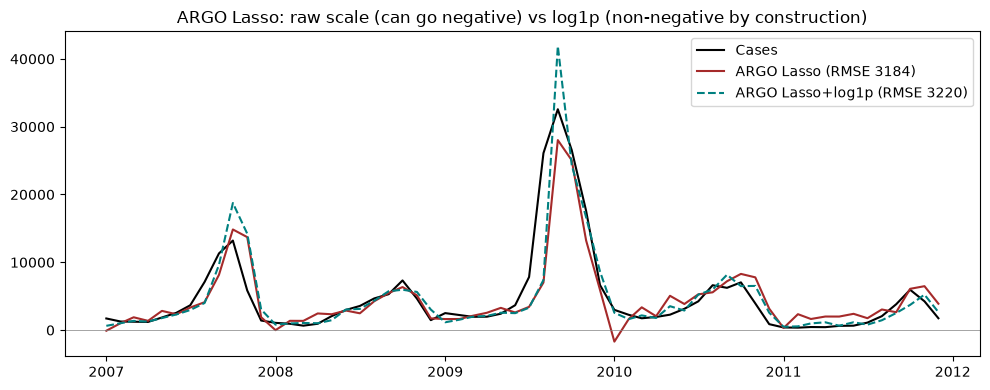

In [8]:
print('min prediction, ARGO least squares:', round(pred_argo.min(), 1))
print('min prediction, ARGO Lasso:        ', round(pred_argo_lasso.min(), 1))
print()

def dynamic_predict_lasso_log(frame, features, window=36):
    preds = np.zeros(frame.shape[0] - window)
    kept_counts = np.zeros(len(features))
    log_target = np.log1p(frame[TARGET])
    log_features = np.log1p(frame[features])
    for month in range(window, frame.shape[0]):
        tr = slice(max(month - window, 2), month)
        model = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50000))
        model.fit(log_features.iloc[tr], log_target.iloc[tr])
        pred_log = model.predict(log_features.iloc[month:month + 1])[0]
        preds[month - window] = np.expm1(pred_log)
        kept_counts += (model.named_steps['lassocv'].coef_ != 0)
    n_negative = int((preds < 0).sum())
    preds = np.clip(preds, 0, None)  # expm1 can dip a hair below 0; clip to a valid count
    return preds, kept_counts, n_negative

pred_argo_lasso_log, kept_counts_log, n_negative = dynamic_predict_lasso_log(dfa, ARGO_FEATURES)
argo_lasso_log_rmse = rmse(df_valid[TARGET], pred_argo_lasso_log)

print('min prediction, ARGO Lasso+log1p:  ', round(pred_argo_lasso_log.min(), 1),
      f'({n_negative}/{len(df_valid)} would have dipped below 0 before clipping)')
print()
print('ARGO least squares      RMSE:', round(argo_rmse, 1))
print('ARGO Lasso              RMSE:', round(argo_lasso_rmse, 1))
print('ARGO Lasso + log1p      RMSE:', round(argo_lasso_log_rmse, 1))
print()
print('How often each term survived Lasso+log1p (nonzero coef), out of', len(df_valid), 'monthly refits:')
for feat, cnt in sorted(zip(ARGO_FEATURES, kept_counts_log), key=lambda x: -x[1]):
    print(f'  {feat:20s} kept {int(cnt):3d}/{len(df_valid)} months ({100*cnt/len(df_valid):.0f}%)')

plt.figure(figsize=(10, 4))
plt.plot(df_valid['Date'], df_valid[TARGET], 'k', label='Cases')
plt.plot(df_valid['Date'], pred_argo_lasso, 'brown', label=f'ARGO Lasso (RMSE {argo_lasso_rmse:.0f})')
plt.plot(df_valid['Date'], pred_argo_lasso_log, 'teal', ls='--', label=f'ARGO Lasso+log1p (RMSE {argo_lasso_log_rmse:.0f})')
plt.axhline(0, color='gray', lw=0.5)
plt.legend(); plt.title('ARGO Lasso: raw scale (can go negative) vs log1p (non-negative by construction)')
plt.tight_layout()
plt.savefig('../mx_dengue_argo_lasso_log1p.png', dpi=150)
plt.show()
